# Exercise 3
### Computer Vision, Fall 2026
#### Name: <font color='blue'>*Sepeteus Rosenlöf*</font>
---
**Instructions:**
- Return the answer in PDF and Jupyter Notebook formats.

- Return latest on<font color='red'> Wednesday 23.9 at 16.00</font> via Moodle.

Disclosure, I used Gemini's guided learning to do these.

## Ex 3.1. Hough Transform (4 p)
Detect edges in the image 'Corridor1.jpg' using OpenCV's Canny edge detector (cv2.Canny).
After finding possible edges, implement yourself a Hough line detector based on the
method presented at the lectures. Use the Hough line detector to detect lines in the given image and visualize your computed lines using Matplotlib.

Your implementation of the Hough line detector should be based on Numpy arrays and not use the OpenCV function for Houghlines. For validation purpose only, you may use OpenCV's built-in functions for computing Hough lines (cv2.HoughLines) to compare its results to yours. 


In [1]:
#imports
import cv2
import numpy as np
from matplotlib import pyplot as plt

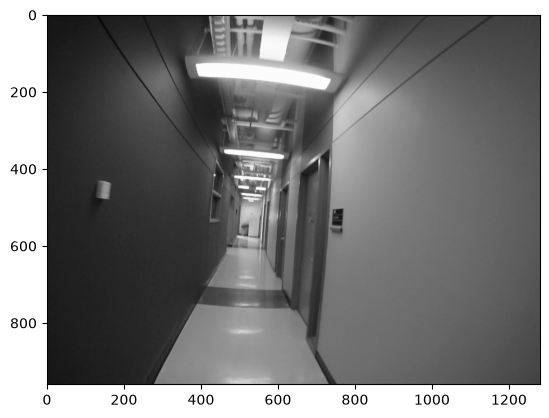

In [2]:
#reading and plotting image
image = cv2.imread("./images/Corridor1.jpg")
image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
plt.figure()
plt.imshow(image, cmap='gray')
plt.show()

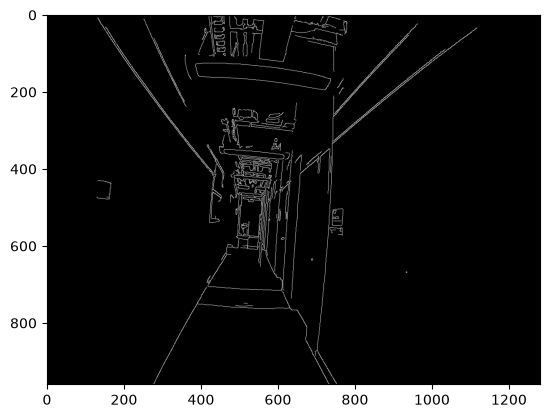

In [3]:
#canny
canny_og = cv2.Canny(image, threshold1=50, threshold2=150)
plt.imshow(canny_og, cmap='gray')
plt.show()

In [5]:
#hough line detection
angles = np.arange(-90, 90, 1)
thetas = np.radians(angles)
height, width = np.shape(image)
rho_max = int(np.sqrt((height**2+width**2)))
#accumulates votes for lines
accumulator = np.zeros((2*int(rho_max), len(thetas)), dtype=np.int32)

type(accumulator[0][0]), \
angles[:3], thetas[:3], \
rho_max, \
np.shape(thetas)


(numpy.int32,
 array([-90, -89, -88]),
 array([-1.57079633, -1.55334303, -1.53588974]),
 1600,
 (180,))

In [6]:
#AI upgraded
edges_row, edges_col = np.where(canny_og == 255)
x = edges_col[:, np.newaxis]
y = edges_row[:, np.newaxis]
rhos = x * np.cos(thetas) + y * np.sin(thetas)
rho_indices = np.round(rhos).astype(int) + rho_max
for j in range(len(thetas)):
    rhos_for_angle = rho_indices[:, j]
    np.add.at(accumulator[:, j], rhos_for_angle, 1)
np.shape(rho_indices)

(19149, 180)

In [83]:
#correct, but slower

# for i, theta in enumerate(thetas):
#     # x is column (horizontal), y is row (vertical)
#     for x, y in zip(edges_col, edges_row):
#         rho = x * np.cos(theta) + y * np.sin(theta)
#         rho_idx = int(round(rho + rho_max))
#         accumulator[rho_idx, i] += 1


#old and a bit wrong
# edges_row, edges_col = np.where(canny_og == 255)

# for i in range(0, len(thetas)):
#     for x, y in zip(edges_row, edges_col):
#         rho = x*np.cos(theta) + y*np.sin(theta)
#         rho_idx = int(rho+rho_max)
#         accumulator[rho_idx, i] += 1
# np.nonzero(accumulator)

# edges[0][:50], edges[1]

(array([1738, 1738, 1738, ..., 2629, 2629, 2629], shape=(160560,)),
 array([  0,   1,   2, ..., 177, 178, 179], shape=(160560,)))

In [7]:
# from scipy.ndimage import maximum_filter
# local_max = maximum_filter(accumulator, size=(15, 15))

# peak_mask = (accumulator == local_max) & (accumulator > 150)
# peak = np.where(peak_mask)
threshold = 125
peak = np.where(accumulator > threshold)
rho = peak[0][0] - rho_max
np.shape(peak), peak, rho

((2, 128),
 (array([1667, 1674, 1677, 1678, 1682, 1683, 1685, 1686, 1687, 1690, 1691,
         1692, 1693, 1694, 1695, 1695, 1696, 1697, 1699, 1700, 1700, 1701,
         1701, 1702, 1703, 1704, 1704, 1705, 1706, 1708, 1709, 1711, 1712,
         1752, 1797, 1808, 1809, 1810, 1811, 1812, 1813, 1814, 1814, 1815,
         1816, 1817, 1818, 1819, 1822, 1823, 1826, 2073, 2097, 2137, 2194,
         2198, 2210, 2214, 2236, 2244, 2260, 2284, 2284, 2285, 2285, 2294,
         2295, 2298, 2299, 2300, 2304, 2304, 2305, 2306, 2307, 2309, 2311,
         2312, 2312, 2313, 2313, 2313, 2314, 2314, 2318, 2319, 2319, 2320,
         2320, 2321, 2321, 2322, 2322, 2323, 2324, 2325, 2326, 2326, 2327,
         2328, 2329, 2329, 2330, 2330, 2332, 2333, 2335, 2336, 2336, 2338,
         2339, 2340, 2340, 2342, 2343, 2344, 2345, 2346, 2346, 2347, 2347,
         2348, 2353, 2360, 2368, 2377, 2378, 2389]),
  array([ 50,  51,  51,  51,  52,  52,  52,  52,  52,  53,  53,  53,  53,
          53,  53,  54,  54,  54,  54

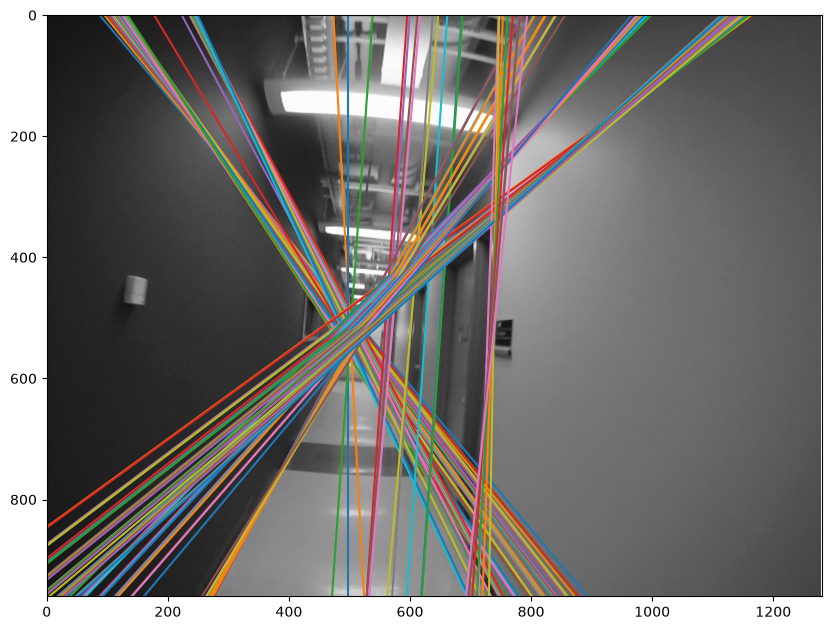

In [9]:
#i had to do this, i've no clue why the original visualizer just didn't want to work.
# Fixed visualization block
width = image.shape[1]
xs = np.array(range(int(width))) # Span across the full image width
plt.figure(figsize=(10, 12))
plt.imshow(image, cmap='gray')

for j in range(len(peak[0])):    
    rho = peak[0][j] - rho_max
    theta = thetas[peak[1][j]]
    
    # Avoid division by zero for near-horizontal theta = 0
    sin_t = np.sin(theta)
    if np.abs(sin_t) < 1e-4:
        # Vertical line: x is constant at rho / cos(theta)
        x_val = rho / np.cos(theta)
        plt.axvline(x=x_val)
    else:
        # Standard line equation: y = (rho - x * cos(theta)) / sin(theta)
        ys = (rho - xs * np.cos(theta)) / sin_t
        plt.plot(xs, ys)

# Constrain display back to original image limits
plt.xlim(0, image.shape[1])
plt.ylim(image.shape[0], 0) # Inverted y-axis for image coordinates
plt.show()



# # visualization with most of the original, looks terrible
# width = image.shape[1]
# height = image.shape[0]

# # 1. Define xs as negative vertical coordinates so -xs maps to positive image Y [0, H]
# xs = -np.arange(height)

# plt.figure(figsize=(20, 30))
# plt.imshow(image, cmap='gray')

# for j in range(len(P[0])):    
#     rho = peak[0][j] - rho_max
#     theta = thetas[peak[1][j]]
    
#     # 2. Compute ys (which becomes the image X coordinate after matrix multiplication)
#     # Using rho = x*cos(theta) + y*sin(theta) where y_image = -xs and x_image = ys
#     # ys = (rho - (-xs) * sin(theta)) / cos(theta)
#     ys = (rho + xs * np.sin(theta)) / (np.cos(theta) + 1e-6)
    
#     lines_fp = np.array([xs, ys])
    
#     # Rotating the lines, so that their origin is image origin (top left)
#     lin = lines_fp.copy()
#     factor = np.array([[0, 1], [-1, 0]])
#     lines_fp = np.dot(factor, lines_fp)
    
#     plt.plot(lines_fp[0], np.abs(lines_fp[1]))

# #visualization
# width = image.shape[1]
# xs = np.array(range(int(width/4)))
# plt.figure(figsize=(20,30))
# plt.imshow(image)

# for j in range(len(P[0])):    
#     #ys = ...
    
#     lines_fp = np.array([xs,ys])
    
#     #Rotating the lines, so that their origin is image origin (top left)
#     lin = lines_fp.copy()
#     factor = np.array([[0,1],[-1,0]])
#     lines_fp= np.dot(factor , lines_fp)
    
#     plt.plot(lines_fp[0],np.abs(lines_fp[1]))



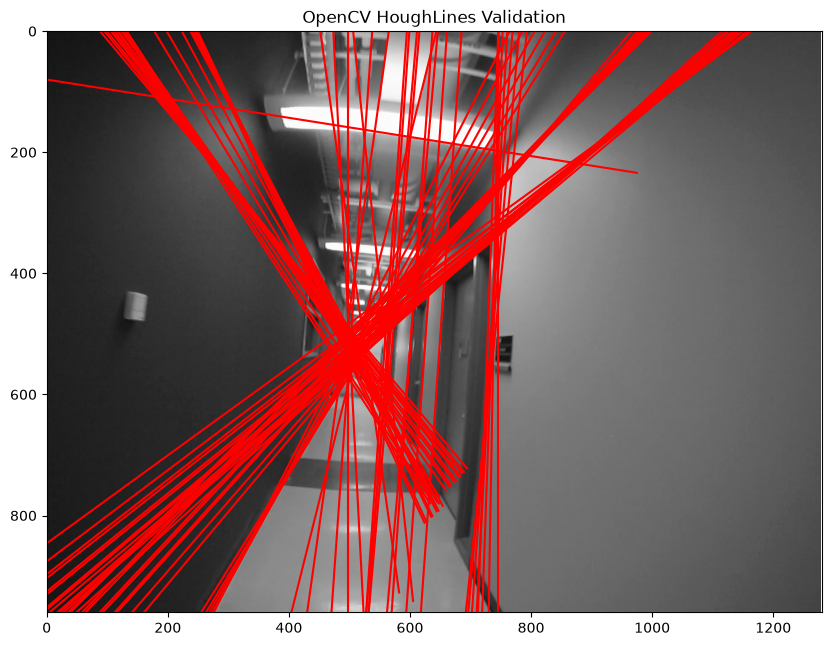

In [16]:
# Validation via OpenCV cv2.HoughLines
cv_lines = cv2.HoughLines(canny_og, rho=1, theta=np.pi / 180, threshold=120)

plt.figure(figsize=(10, 15))
plt.imshow(image, cmap='gray')

if cv_lines is not None:
    for line in cv_lines:
        rho, theta = line[0]
        a = np.cos(theta)
        b = np.sin(theta)
        x0 = a * rho
        y0 = b * rho
        x1 = int(x0 + 1000 * (-b))
        y1 = int(y0 + 1000 * (a))
        x2 = int(x0 - 1000 * (-b))
        y2 = int(y0 - 1000 * (a))
        plt.plot([x1, x2], [y1, y2], color="red")

plt.xlim([0, image.shape[1]])
plt.ylim([image.shape[0], 0])
plt.title("OpenCV HoughLines Validation")
plt.show()

# Pondering

The custom system's lines appear to be ever so slightly better than the OpenCV version. It is very odd.


## Ex 3.2 Hough Circle Transform (4 p)

Detect edges in the image 'Coins.jpg' using OpenCV's Canny edge detector (cv2.Canny). After finding possible edges, implement yourself a Hough circle detector based on the Hough transform method presented at the lectures.

Assume that the radii of the circles are within the range of 20 to 50 pixels. For each edge point (x,y), vote for possible circle centers (a,b) and radii r using the circle parametrization

$a = x−rcosθ,$
$b = y−rsinθ$

where θ represents the angle around the circle.

Construct a Hough accumulator for the parameters $(a,b,r)$, and use the accumulator to detect the circles in the image. Visualize your detected circles on the original image using Matplotlib.

Your implementation of the Hough circle detector should be based on NumPy arrays and not use OpenCV's function for Hough circles. For validation purpose only, you may use OpenCV's built-in function for computing Hough circles (cv2.HoughCircles) to compare its results to yours.


In [17]:
# imports
import cv2
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle

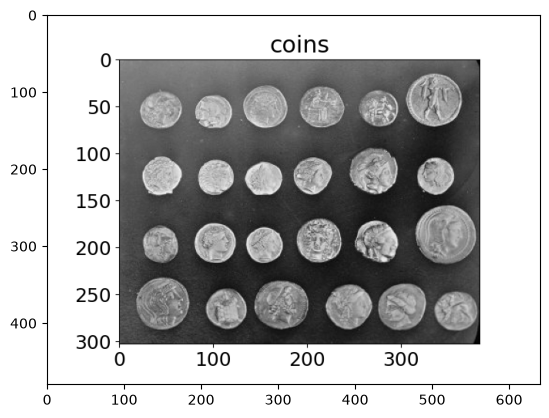

In [18]:
#reading and plotting image
image = cv2.imread("./images/coins.png")
image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
plt.figure()
plt.imshow(image, cmap='gray')
plt.show()

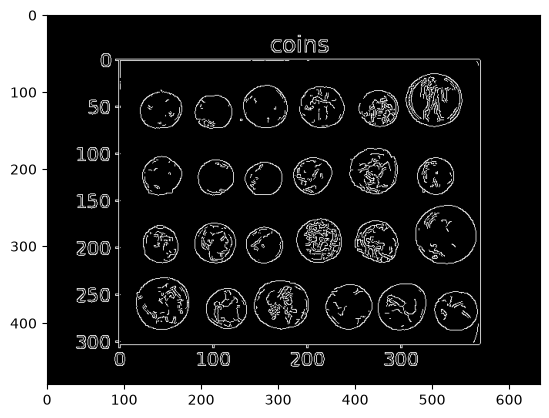

In [19]:
#canny
canny_coins = cv2.Canny(image, threshold1=150, threshold2=250)
plt.imshow(canny_coins, cmap='gray')
plt.show()

In [20]:
height,width = np.shape(canny_coins)
radii = np.arange(20, 50, 1)
accumulator = np.zeros((height, width, len(radii)), dtype=np.int32)

# np.shape(canny_coins)

In [21]:
#new and fast
thetas = np.linspace(0, 2 * np.pi, 180)
cos_thetas = np.cos(thetas)
sin_thetas = np.sin(thetas)
edge_y, edge_x = np.where(canny_coins != 0)
# edge_y, edge_x = np.nonzero(canny_coins)
for r_idx, r in enumerate(radii):
    a = np.round(edge_x[:, np.newaxis] - r*cos_thetas[np.newaxis, :]).astype(int)
    b = np.round(edge_y[:, np.newaxis] - r*sin_thetas[np.newaxis, :]).astype(int)
    # 0 <= a < width, 0 <= b < height
    mask_a = (0 <= a) & (a < width)
    mask_b = (0 <= b) & (b < height)
    valid_mask = mask_a & mask_b
    valid_a = a[valid_mask]
    valid_b = b[valid_mask]
    #voting
    np.add.at(accumulator[:, :, r_idx], (valid_b, valid_a), 1)



#old, incomplete and slow
# candidate_centers = []
# for i, r in enumerate(radii):
#     for theta in np.deg2rad(np.arange(0,360,1)):
#         a = int(edge_x[i] - (r*np.cos(theta)))
#         b = int(edge_y[i] - (r*np.sin(theta)))
#         candidate_centers.append((a,b))
# coords_y, coords_x 

In [22]:
#threshold selection
threshold = 60
b_idxs, a_idxs, r_idxs = np.where(accumulator >= threshold)
sorted_accumulator_idxs = np.argsort(accumulator[b_idxs, a_idxs, r_idxs])[::-1]
final_circles = []
distance_threshold = 30

for idx in sorted_accumulator_idxs:
    a_cand = a_idxs[idx]
    b_cand = b_idxs[idx]
    r_cand = radii[r_idxs[idx]]
    
    # Check distance against already accepted circles
    is_too_close = False
    for (a_acc, b_acc, r_acc) in final_circles:
        dist = np.hypot(a_cand - a_acc, b_cand - b_acc)
        if dist < distance_threshold:
            is_too_close = True
            break
            
    if not is_too_close:
        final_circles.append((a_cand, b_cand, r_cand))

len(final_circles)

24

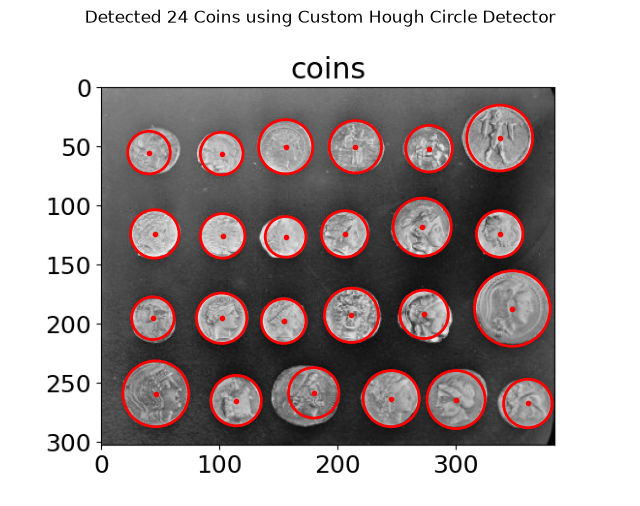

In [23]:
plt.figure(figsize=(8, 8))
plt.imshow(image, cmap='gray')

# Get current axes object
ax = plt.gca()

# Draw all detected circles
for a, b, r in final_circles:
    # 1. Create the circle patch
    circle_patch = plt.Circle((a, b), r, color='red', fill=False, linewidth=2)
    
    # 2. Add patch to axes
    ax.add_patch(circle_patch)
    
    # 3. Mark the center point with a small dot
    plt.plot(a, b, 'ro', markersize=3)

plt.title(f"Detected {len(final_circles)} Coins using Custom Hough Circle Detector")
plt.axis('off') # Hide pixel grid axes for a cleaner look
plt.show()

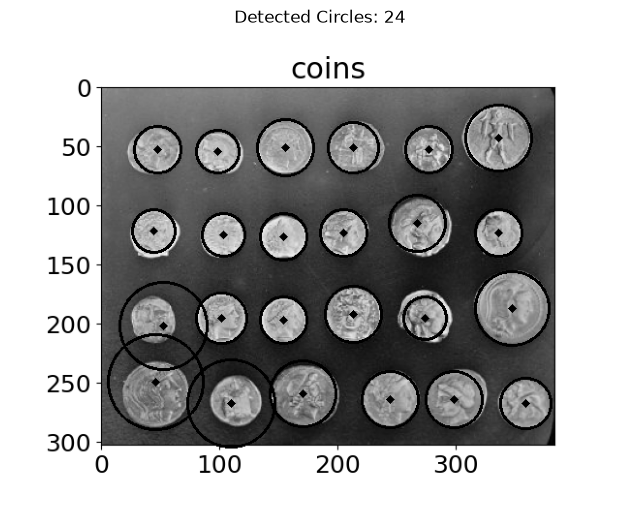

In [24]:
import cv2

# Run OpenCV built-in version for validation
cv_circles = cv2.HoughCircles(
    image, 
    cv2.HOUGH_GRADIENT, 
    dp=1, 
    minDist=55, 
    param1=50, 
    param2=32, 
    minRadius=20, 
    maxRadius=50
)

# Make a copy of the image to avoid modifying the original
output_image = image.copy()

# cv2.HoughCircles returns a 3D array: (1, N, 3) -> [[[x, y, r], ...]]
if cv_circles is not None:
    # Convert parameters (x, y, radius) to rounded integers
    cv_circles = np.uint16(np.around(cv_circles))
    
    for pt in cv_circles[0, :]:
        x, y, r = pt[0], pt[1], pt[2]
        
        # 1. Draw the circle boundary (Green, thickness = 2)
        cv2.circle(output_image, (x, y), r, (0, 255, 0), 2)
        
        # 2. Draw the center point (Red, thickness = 3)
        cv2.circle(output_image, (x, y), 2, (0, 0, 255), 3)

# Display using Matplotlib
plt.figure(figsize=(8, 8))

# Convert BGR to RGB if original image is color
if len(output_image.shape) == 3:
    output_image = cv2.cvtColor(output_image, cv2.COLOR_BGR2RGB)
    plt.imshow(output_image)
else:
    plt.imshow(output_image, cmap='gray')

plt.title(f"Detected Circles: {len(cv_circles[0]) if cv_circles is not None else 0}")
plt.axis('off')
plt.show()

# Pondering

The results of the official one are weirdly worse than the custom implementation's.

## Ex 3.3 Direct Linear Transformation (4 p)

Implement the normalized DLT (Direct Linear Transformation) algorithm
1) Take two images e.g. with your smartphone while rotating the phone a few degrees in between.

2) Detect features from those images using OpenCv's SIFT detector and OpenCV's BFFMatcher (https://docs.opencv.org/3.4/da/df5/tutorial_py_sift_intro.html and https://docs.opencv.org/4.x/dc/dc3/tutorial_py_matcher.html)

3) Compute the 3x3 homography matrix H procedure such that xi’=Hxi (in homogenous coordinates) using DLT and at least 4-point correspondences.

To get improved performance normalize the points using the following algorithm:
- Normalize points xi: First move their average to (0,0) by substracting their mean. Then scale them to average length of 2 . The final transformation is: T= Tscale*Ttranslate 

- Do the same to points xi’, and obtain the transformation T’ For each correspondence xi ↔xi’ compute the matrix Ai (using the transformed points); see explanation and definitions from lecture slides. Assemble the n 2x9 matrices Ai into a single 2nx9 matrix A. Obtain the SVD of A. Here you can use Numpys SVD function. The unit singular vector corresponding to the smallest singular value is the solution h. Specifically, if A=UDVT with D diagonal with positive diagonal entries, arranged in descending order down the diagonal, then h is the last column of V. Denormalize the solution: inv(T’)*H*T.

(“Multiple View Geometry in computer vision”, by R. Hartley and A. Zisserman, p. 92)

In [26]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

In [27]:
#read in images
img1_path = "./images/mugsun1.jpg" 
img2_path = "./images/mugsun2.jpg"
I1 = cv2.imread(img1_path)
I1 = cv2.cvtColor(I1, cv2.COLOR_BGR2GRAY)
I2 = cv2.imread(img2_path)
I2 = cv2.cvtColor(I2, cv2.COLOR_BGR2GRAY)

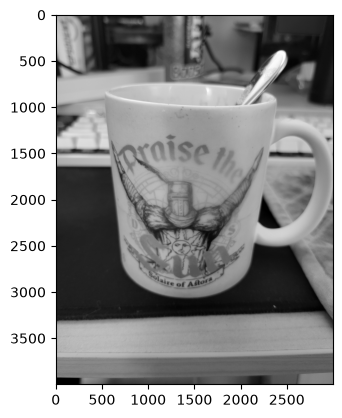

In [205]:
plt.imshow(I1, cmap='gray')

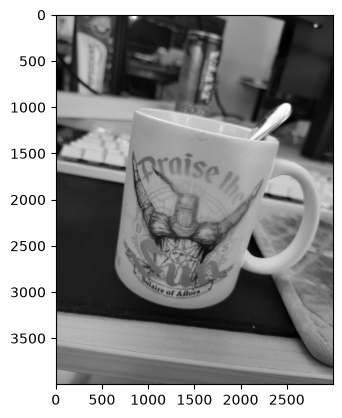

In [206]:
plt.imshow(I2, cmap='gray')


In [30]:
#feature extraction
import cv2
import numpy as np

# Detect keypoints and descriptors
sift = cv2.SIFT_create()
kp1, des1 = sift.detectAndCompute(I1, None)
kp2, des2 = sift.detectAndCompute(I2, None)

In [31]:
#feature matching

# Match descriptors
bf = cv2.BFMatcher()
matches = bf.knnMatch(des1, des2, k=2)

# Apply Lowe's ratio test to filter good matches
good_matches = []
for m, n in matches:
    if m.distance < 0.75 * n.distance:
        good_matches.append(m)

< cv2.DMatch 0x7f6df035bed0>

In [64]:
#generating 2 sets of homogeneous points

# Extract 2D locations of keypoints
#queryIdx = set of features searching from -- stores the index of kp1
#trainIdx = set of features matching into -- stores the index of kp2
pts1 = np.float32([kp1[m.queryIdx].pt for m in good_matches])
pts2 = np.float32([kp2[m.trainIdx].pt for m in good_matches])

pts1 = np.hstack([pts1, np.ones((pts1.shape[0], 1))])
pts2 = np.hstack([pts2, np.ones((pts2.shape[0], 1))])

np.shape(pts1), pts1[:], len(pts1)

((519, 3),
 array([[9.09420166e+01, 1.28552698e+03, 1.00000000e+00],
        [1.04791893e+02, 1.44565201e+02, 1.00000000e+00],
        [1.49137436e+02, 5.77699036e+02, 1.00000000e+00],
        ...,
        [2.91010986e+03, 2.20673755e+03, 1.00000000e+00],
        [2.92287305e+03, 3.16566479e+03, 1.00000000e+00],
        [2.98136255e+03, 3.60133447e+03, 1.00000000e+00]], shape=(519, 3)),
 519)

In [136]:
#Takes in 2d points in homogeneous coordinates and returns normalized coordinates and the normalization matrix
def normalize(points):
    #means
    mean_pts_x = np.mean(points[:, 0])
    mean_pts_y = np.mean(points[:, 1])

    #centers
    center_pts_x = points[:, 0] - mean_pts_x
    center_pts_y = points[:, 1] - mean_pts_y


    avg_distance = (1/len(points)) * (np.sum(np.sqrt((center_pts_x**2) + (center_pts_y**2))))
    
    #scale
    s = np.sqrt(2)/avg_distance

    T_translate = np.array([
        [1,0,-mean_pts_x],
        [0,1,-mean_pts_y],
        [0,0,1]
    ])

    T_scale = np.array([
        [s,0,0],
        [0,s,0],
        [0,0,1]
    ])

    T = T_scale @ T_translate
    # print(T, '\n\n', T_translate, '\n\n', T_scale, '\n', s, avg_distance)
    # print(len(points), avg_distance)
    norm_pts = (T @ points.T).T
    print(np.shape(norm_pts) )
    return norm_pts, T

In [140]:
#apply normalizing function
norm_pts1 = normalize(pts1)
norm_pts2 = normalize(pts2)
np.shape(norm_pts1[0])

(519, 3)
(519, 3)


(519, 3)

In [198]:
#build A matrix according to the slides

N = norm_pts1[0].shape[0]
A = []

for i in range(N):
    x, y, w = norm_pts1[0][i]    # w is 1
    xp, yp, wp = norm_pts2[0][i] # wp is 1
    
    row1 = [0, 0, 0, -x, -y, -1, yp*x, yp*y, yp]
    row2 = [x, y, 1, 0, 0, 0, -xp*x, -xp*y, -xp]
    
    A.append(row1)
    A.append(row2)

A = np.array(A)
np.shape(A)
#old attempt, no good
# M_y = norm_pts1[0] @ norm_pts2[0].T
# M_x = norm_pts1[0].T @ -(norm_pts2[0][:, 0])
# neg_points = -norm_pts1[0]
# zeros = norm_pts1[0]*0
# M_stack = np.hstack((zeros,neg_points))
# M2_stack = np.hstack((norm_pts1[0],zeros))
# M3_stack = np.vstack((M_stack, M2_stack))
# # final_stack = np.hstack((M3_stack,M_y))
# # M1_x = norm_pts1[1] @ norm_pts2[0][:, 0].T
# # # A = norm_pts1[0].T @ norm_pts2[0]
# np.shape(norm_pts1[0]), \
# np.shape(norm_pts2[0][:,0]),\
# np.shape(M_y), \
# np.shape(M_stack), \
# np.shape(M3_stack), \
# zeros

(1038, 9)

In [200]:
#compute svd
u,s,v =np.linalg.svd(A)
H = v[-1].reshape(3,3)

np.shape(H)

(3, 3)

In [202]:
#denormalize solution
T = norm_pts1[1]
T_prime = norm_pts2[1]
H = np.linalg.inv(T_prime)@H@T

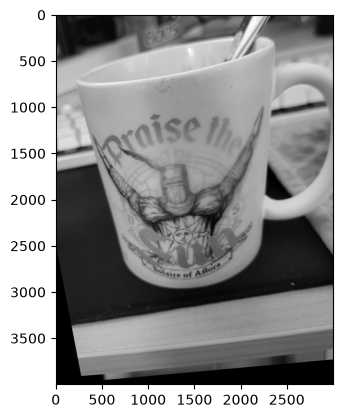

In [204]:
#use cv2.warpPerspective to visualize the homography matrix H
im_dst = cv2.warpPerspective(I1, np.linalg.inv(H), (I1.shape[1],I1.shape[0]))
plt.imshow(im_dst, cmap="gray")